# Influence on Outcomes

Variable of Interest and Covariates
- y_hat = percentage differences in avoided emissions
- x1 = region (cat)
- x2 = time of day (cat)
- x3 = amount of flex time (float)

Methods
- CPQE analysis
- OLS
    - log transformed y value

In [23]:
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

In [ ]:
df = pd.read_csv("/Users/jen/watttime-python-client/tests/data/naive/PSEI_naive_logodds.csv")

In [ ]:
def categorize_time(hour):
    if hour < 6:
        return 'Night'
    elif hour < 12:
        return 'Morning'
    elif hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'
    

df["hour"] = pd.to_datetime(df.usage_window_start).dt.hour
df["month"] = pd.to_datetime(df.usage_window_start).dt.month
df["time_of_day"] = df["hour"].apply(categorize_time)
df["increments_flex_time"] = round(df["flex_time"]/15,2)

df["forecast_error"] = df["forecast"] - df["actual"]
df["forecast_percent_error"] = df["forecast_error"]/df["actual"]

- cumulative avoided emissions over 1000 synthetic charging sessions

<Axes: >

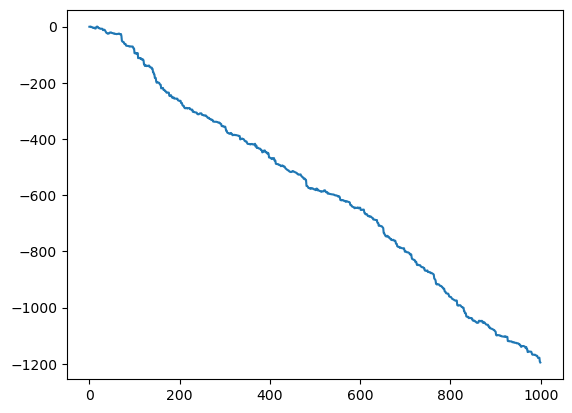

In [52]:
df.change_in_emissions.cumsum().plot()

<Axes: >

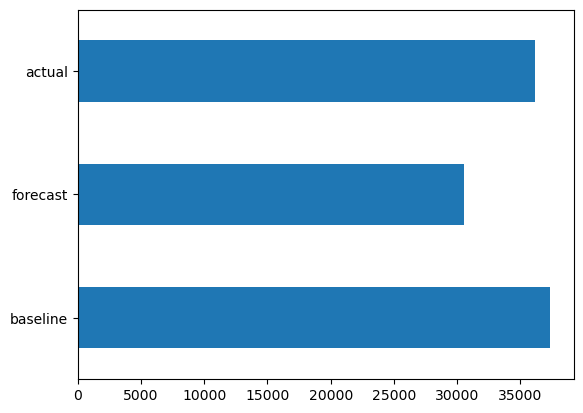

In [184]:
df[["baseline","forecast","actual"]].sum().plot(kind="barh")

- A negative value indicates avoided emissions, a positive value indicated accrued emissions

<Axes: >

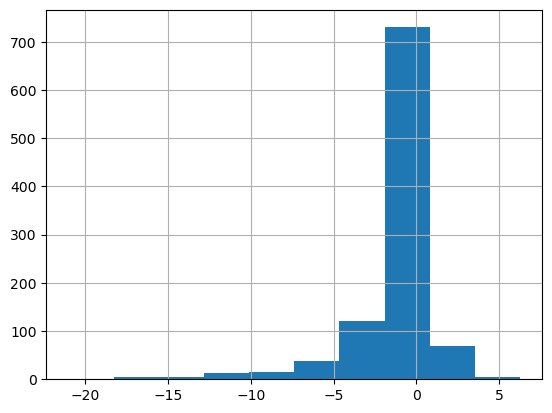

In [10]:
df.change_in_emissions.hist()

- Time available within the session window to shift the time at which charging occurs. Flex_time of 0 would indicate that the user will stop the session at the moment of full charge, allowing no time for optimization.

<Axes: >

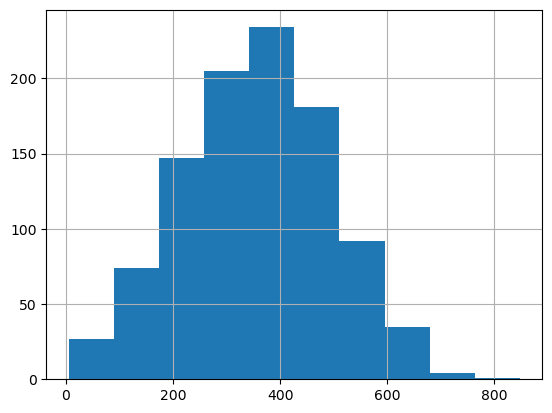

In [12]:
df.flex_time.hist()

- Time needed to reach full charge.

<Axes: >

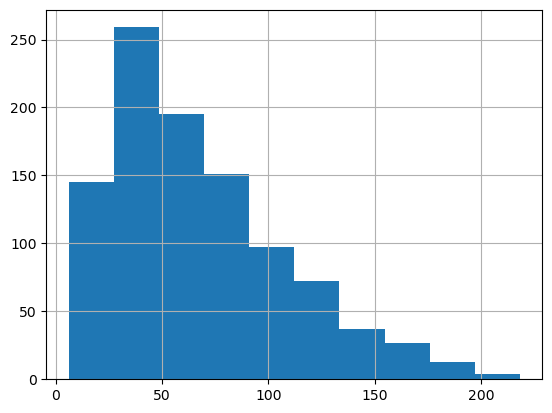

In [13]:
df.time_needed.hist()

- Difference between forecast and actual. An indication of how closely the moer value accuracy, not an indication of rank order accuracy which focuses on the correctness of the order of items in a ranking system.

<Axes: >

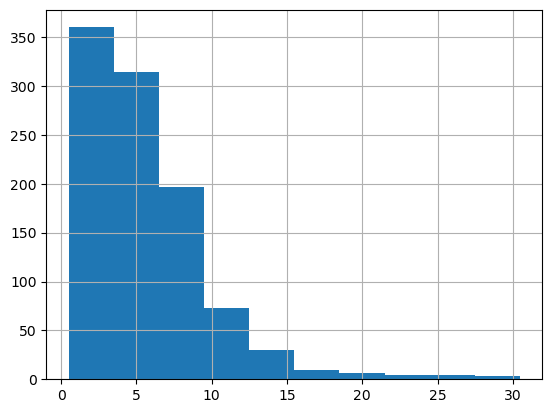

In [16]:
df["forecast_error"].hist()

<Axes: >

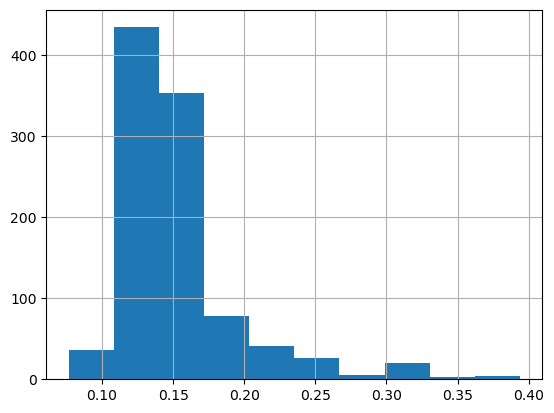

In [121]:
df["forecast_percent_error"].hist()

<Axes: >

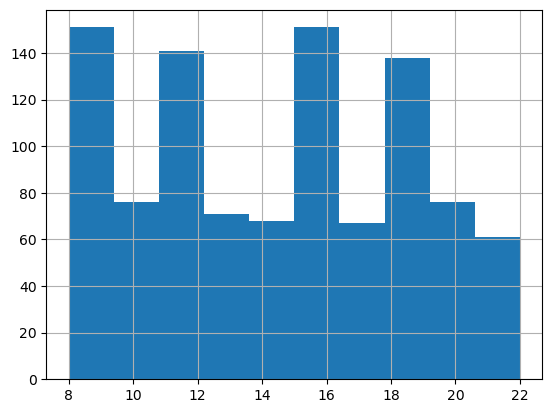

In [22]:
df["hour"].hist()

In [21]:
df[["flex_time","change_in_emissions"]].corr()

,flex_time,change_in_emissions
flex_time,1.000000,-0.074068
change_in_emissions,-0.074068,1.000000


<Axes: >

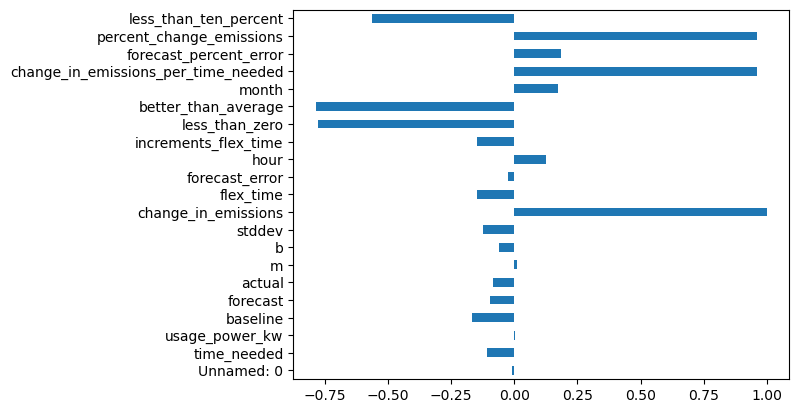

In [188]:
df.corr(numeric_only=True,method="spearman")["change_in_emissions"].plot(kind="barh")

## Log Odds

- A logistic regression model allows us to establish a relationship between a binary outcome variable and a group of predictor variables. 

Outcome Variables
- `Less than zero`: failure/success of optimizer decreasing emissions compared to baseline
- `Better than average`: failure/success of optimizer decreasing emissions more than the average reduction achieved by optimizer

Predictor Variables
- `increments_flex_time`: Amount of flex time provided at session start. A unit of 1 = 15 minutes.
- `forecast_percent_error`: Difference between forecast + actual values. This would typically be in the error term of the equation, but since we know it we can control for it.
- `time_of_day`: If the session started in the morning, afternoon, or evening.
- `time_needed`: Total time needed to reach full charge

In [215]:
def log_odds(p):
    odds = p / (1 - p)
    return np.log(odds)

In [189]:
df["less_than_zero"] = df["change_in_emissions"] < 0
df["better_than_average"] = df["change_in_emissions"] < df["change_in_emissions"].mean()

df["less_than_zero"]=df["less_than_zero"].astype(int)
df["better_than_average"]=df["better_than_average"].astype(int)

- The probability of the optimizer beating the baseline is .719

In [191]:
df["less_than_zero"].value_counts(normalize=False)

less_than_zero
1    719
0    281
Name: count, dtype: int64

- The probability of the optimizer performing better than average is .72

In [40]:
df["better_than_average"].value_counts(normalize=True)

better_than_average
0    0.71
1    0.29
Name: proportion, dtype: float64

In [195]:
model = smf.logit(formula='less_than_zero ~ increments_flex_time + C(time_of_day) + time_needed + forecast_percent_error', data=df)
model.fit().summary()

Optimization terminated successfully.
         Current function value: 0.547756
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         less_than_zero   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      994
Method:                           MLE   Df Model:                            5
Date:                Fri, 11 Apr 2025   Pseudo R-squ.:                 0.07769
Time:                        10:14:48   Log-Likelihood:                -547.76
converged:                       True   LL-Null:                       -593.90
Covariance Type:            nonrobust   LLR p-value:                 2.230e-18
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     0.9485      0.381      2.489      0.013       0.202       1.695
C(time_of_day)[T.Evening]     0.9930      0.192      5.173      0.000       0.617       1.369
C(time_of_day)[T.Morning]     0.7634      0.179      4.267      0.000       0.413       1.114
increments_flex_time          0.0351      0.009      4.130      0.000       0.018       0.052
time_needed                   0.0025      0.002      1.333      0.182      -0.001       0.006
forecast_percent_error       -9.2715      1.649     -5.621      0.000     -12.504      -6.039
=============================================================================================
"""

In [196]:
results = model.fit().params

Optimization terminated successfully.
         Current function value: 0.547756
         Iterations 6


In [197]:
results

Intercept                    0.948474
C(time_of_day)[T.Evening]    0.993021
C(time_of_day)[T.Morning]    0.763358
increments_flex_time         0.035125
time_needed                  0.002517
forecast_percent_error      -9.271536
dtype: float64

In [198]:
i = results[0]
eve = results[1]
morn = results[2]
f = results[3]
t = results[4]
e = results[5]

/var/folders/kf/cqbq1hkx74v5lt73jq2w60x40000gn/T/ipykernel_28568/262189549.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  i = results[0]
/var/folders/kf/cqbq1hkx74v5lt73jq2w60x40000gn/T/ipykernel_28568/262189549.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eve = results[1]
/var/folders/kf/cqbq1hkx74v5lt73jq2w60x40000gn/T/ipykernel_28568/262189549.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  morn = results[2]
/var/

For an session with time needed requirement of 67.5 minutes, 30 minutes of flex time, and average forecast error:
- 44% chance of optimization in the afternoon
- 63% chance of optimization in the morning
- 68% chance of optimization in the evening

Relationship between flex time and outcomes:
- For each additional increment of flex time, the probability of a positive outcome increases by ~1 percentage point.

In [199]:
average_time_needed = df.time_needed.mean()
inc_count = 2
average_e = df.forecast_percent_error.mean()

In [ ]:
np.exp(i + f*inc_count+t*average_time_needed + e*average_e) / (1 + np.exp(i + f*inc_count+t*average_time_needed+e*average_e))

0.4440663070523712

In [131]:
np.exp(i + f*inc_count+t*average_time_needed + morn+ e*average_e) / (1 + np.exp(i + f*inc_count+t*average_time_needed + morn+ e*average_e)) # probability of optimization - morning

0.6315060728269948

In [132]:
np.exp(i + f*inc_count+t*average_time_needed + eve+ e*average_e) / (1 + np.exp(i + f*inc_count+t*average_time_needed + eve+ e*average_e)) # probability of optimization - evening

0.6831628561637235

In [134]:
inc_count = 4

In [202]:
# increase odds of optimization by 1% for every 15 additional minutes of flex time
np.exp((i + f*2+t*average_time_needed + eve+ e*average_e)- (i + f*1+t*average_time_needed + eve+ e*average_e))

1.035749339734274

# Visualizations

In [203]:
import seaborn as sns

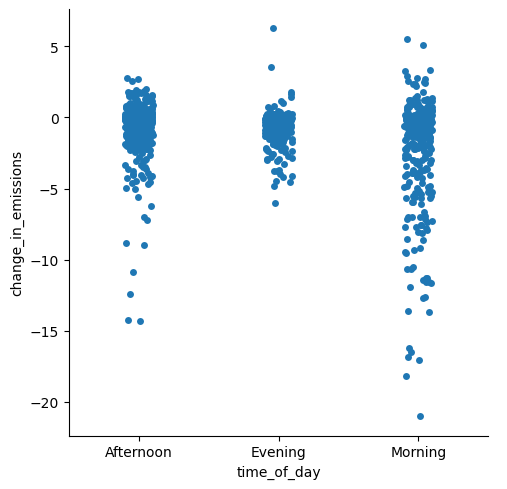

In [89]:
sns.catplot(
    data=df,
    y = "change_in_emissions",
    x = "time_of_day"
)

In [98]:
df["change_in_emissions_per_time_needed"] = df["change_in_emissions"]/df["time_needed"]

- Least error prone in the evenings
- Greater opportunity for gains during the day

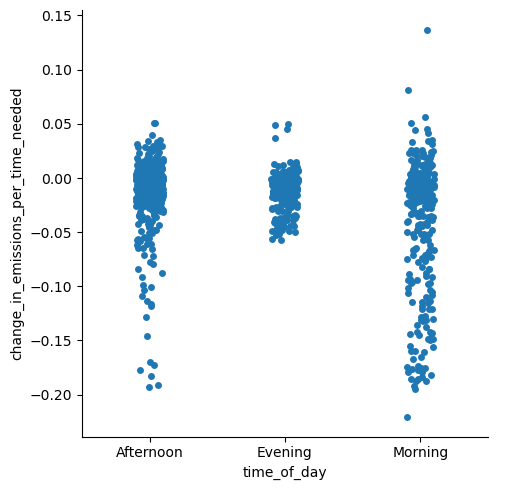

In [99]:
sns.catplot(
    data=df,
    y = "change_in_emissions_per_time_needed",
    x = "time_of_day"
)

Likes a downward sloping forecast, that's when you naturally see most difference from baseline

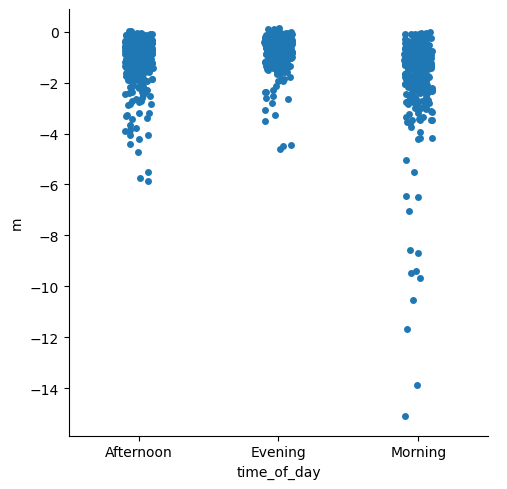

In [182]:
sns.catplot(
    data=df,
    y = "m",
    x = "time_of_day"
)

# Maximal Emissions Reductions

Outcome Variables
- `percent change emissions`: percent change avoided emissions.
- `less_than_eight_percent`:" failure/success of a session improving avoided emissions by 8 percentage points. A highly successful session for the region

Predictor Variables
- `increments_flex_time`: Amount of flex time provided at session start. A unit of 1 = 15 minutes.
- `forecast_percent_error`: Difference between forecast + actual values. This would typically be in the error term of the equation, but since we know it we can control for it.
- `time_of_day`: If the session started in the morning, afternoon, or evening.
- `time_needed`: Total time needed to reach full charge

In [204]:
df["percent_change_emissions"] = df["change_in_emissions"]/df["baseline"]*100

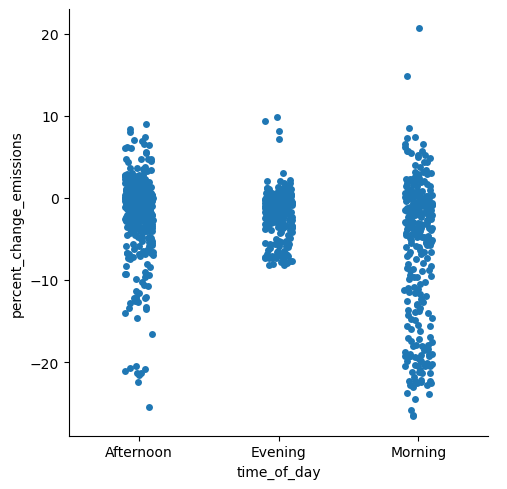

In [143]:
sns.catplot(
    data=df,
    y = "percent_change_emissions",
    x = "time_of_day"
)

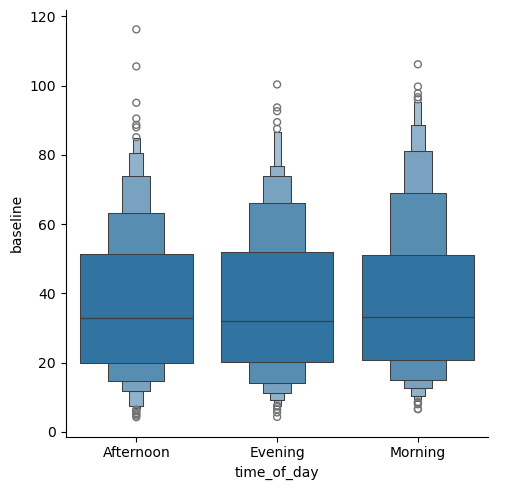

In [180]:
sns.catplot(
    data=df,
    y = "baseline",
    x = "time_of_day",
    kind = "boxen"
)

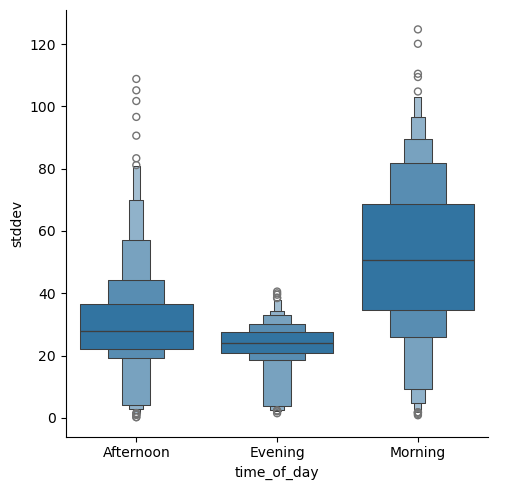

In [181]:
sns.catplot(
    data=df,
    y = "stddev",
    x = "time_of_day",
    kind = "boxen"
)

In [205]:
df["less_than_eight_percent"] = df["percent_change_emissions"] < -8
df["less_than_eight_percent"]=df["less_than_eight_percent"].astype(int)

In [206]:
df["less_than_eight_percent"].value_counts(normalize=True)

less_than_eight_percent
0    0.861
1    0.139
Name: proportion, dtype: float64

In [207]:
model = smf.logit(formula='less_than_eight_percent ~ increments_flex_time + C(time_of_day) + forecast_error', data=df)
model.fit().summary()

Optimization terminated successfully.
         Current function value: 0.320474
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                              Logit Regression Results                             
===================================================================================
Dep. Variable:     less_than_eight_percent   No. Observations:                 1000
Model:                               Logit   Df Residuals:                      995
Method:                                MLE   Df Model:                            4
Date:                     Fri, 11 Apr 2025   Pseudo R-squ.:                  0.2051
Time:                             10:23:17   Log-Likelihood:                -320.47
converged:                            True   LL-Null:                       -403.14
Covariance Type:                 nonrobust   LLR p-value:                 1.046e-34
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -3.4682      0.410     -8.465      0.000      -4.271      -2.665
C(time_of_day)[T.Evening]    -2.1647      0.606     -3.573      0.000      -3.352      -0.977
C(time_of_day)[T.Morning]     1.7824      0.216      8.265      0.000       1.360       2.205
increments_flex_time          0.0463      0.012      3.917      0.000       0.023       0.069
forecast_error               -0.0133      0.025     -0.537      0.591      -0.062       0.035
=============================================================================================
"""

In [208]:
results = model.fit().params

Optimization terminated successfully.
         Current function value: 0.320474
         Iterations 9


In [209]:
i = results[0]
eve = results[1]
morn = results[2]
f = results[3]
e = results[4]

/var/folders/kf/cqbq1hkx74v5lt73jq2w60x40000gn/T/ipykernel_28568/702933150.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  i = results[0]
/var/folders/kf/cqbq1hkx74v5lt73jq2w60x40000gn/T/ipykernel_28568/702933150.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  eve = results[1]
/var/folders/kf/cqbq1hkx74v5lt73jq2w60x40000gn/T/ipykernel_28568/702933150.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  morn = results[2]
/var/

In [210]:
inc_count = 2

In [211]:
np.exp(i + f*inc_count + e*average_e) / (1 + np.exp(i + f*inc_count+e*average_e)) # probability of optimization - afternoon

0.03299933570099601

In [212]:
np.exp(i + f*inc_count + e*average_e + morn) / (1 + np.exp(i + f*inc_count+e*average_e + morn)) # probability of optimization - morning

0.16864093140454217

In [213]:
np.exp(i + f*inc_count + e*average_e + eve) / (1 + np.exp(i + f*inc_count+e*average_e + eve)) # probability of optimization - evening

0.0039018069681810105

In [214]:
# increase odds of optimization by 1% for every 15 additional minutes of flex time
np.exp((i + f*2+ morn + e*average_e)- (i + f*1+ morn + e*average_e))

1.0473408900806247